In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from scipy.stats import *
from statsmodels.stats.contingency_tables import Table2x2
from statsmodels.stats.multitest import multipletests


# %matplotlib.inline 

In [2]:
# !pip install sqlalchemy pyodbc pandas

In [3]:
server = r"(localdb)\ProjectModels"
database = "Hr_analytics"

connection_string = quote_plus(
    f"DRIVER={{ODBC Driver 17 for SQL Server}};"
    f"SERVER={server};"
    f"DATABASE={database};"
    f"Trusted_Connection=yes;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={connection_string}")
query = """
SELECT  *
FROM PROCESSED.employees;
"""

data = pd.read_sql(query, engine)


c:\Users\user\anaconda3\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.4025.3'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


In [4]:
data.head()

,EmployeeNumber,Age,Gender,MaritalStatus,Department,JobRole,JobLevel,BusinessTravel,Education,EducationField,...,WorkLifeBalance,JobInvolvement,PerformanceRating,DistanceFromHome,OverTime,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition
0,1,41,Female,Single,Sales,Sales Executive,2,Travel_Rarely,2,Life Sciences,...,1,3,3,1,Yes,6,4,0,5,Yes
1,2,49,Male,Married,Research & Development,Research Scientist,2,Travel_Frequently,1,Life Sciences,...,3,2,4,8,No,10,7,1,7,No
2,4,37,Male,Single,Research & Development,Laboratory Technician,1,Travel_Rarely,2,Other,...,3,2,3,2,Yes,0,0,0,0,Yes
3,5,33,Female,Married,Research & Development,Research Scientist,1,Travel_Frequently,4,Life Sciences,...,3,3,3,3,Yes,8,7,3,0,No
4,7,27,Male,Married,Research & Development,Laboratory Technician,1,Travel_Rarely,1,Medical,...,3,3,3,2,No,2,2,2,2,No


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeNumber            1470 non-null   int64 
 1   Age                       1470 non-null   int64 
 2   Gender                    1470 non-null   object
 3   MaritalStatus             1470 non-null   object
 4   Department                1470 non-null   object
 5   JobRole                   1470 non-null   object
 6   JobLevel                  1470 non-null   int64 
 7   BusinessTravel            1470 non-null   object
 8   Education                 1470 non-null   int64 
 9   EducationField            1470 non-null   object
 10  TotalWorkingYears         1470 non-null   int64 
 11  NumCompaniesWorked        1470 non-null   int64 
 12  TrainingTimesLastYear     1470 non-null   int64 
 13  MonthlyIncome             1470 non-null   int64 
 14  PercentSalaryHike       

# Introduction 
----

Dans ce notebook, nous allons nous concentrer sur la **dimension statistique des données RH** afin d’identifier les variables les plus discriminantes vis-à-vis de l’attrition des collaborateurs.

L’objectif est de construire une sélection de variables statistiquement pertinentes pour les étapes suivantes du projet, notamment la **segmentation des employés** et la **modélisation prédictive du risque d’attrition**.

Compte tenu de la forme de plusieurs distributions observées dans le jeu de données, notamment des distributions asymétriques et étalées vers la droite, nous privilégierons principalement des **tests statistiques non paramétriques** pour l’analyse des variables numériques.

Pour les variables catégorielles, nous utiliserons notamment le **test du Chi² d’indépendance**, complété par des mesures de force d’association telles que le **V de Cramér**, afin de distinguer une simple significativité statistique d’une association réellement notable avec l’attrition.

Enfin, une attention particulière sera portée à la **redondance entre variables**. Nous analyserons les corrélations afin d’éviter de sélectionner plusieurs variables apportant une information très similaire, ce qui pourrait introduire de la multicolinéarité, réduire l’interprétabilité des modèles et complexifier inutilement les analyses suivantes.

La sélection finale reposera donc sur une combinaison de **significativité statistique, taille d’effet, force d’association, redondance entre variables et pertinence métier**.


# 1.1 Test statistique ( Variable Num vs Attrition )

In [6]:
df = data.copy()
df.drop(columns = ['EmployeeNumber'] , axis = 1 , inplace = True)

In [7]:
df.loc[:, ["Attrition", "OverTime"]] =(
df.loc[ : , ['Attrition','OverTime']]
.map(lambda x: 1 if x == "Yes" else 0)
)

In [8]:
y = "Attrition"
X = df.columns[df.columns != "Attrition"]

In [9]:
numeric_features = df.select_dtypes(include = ["float" , "int"]).columns.tolist()
categorical_features = [var for var in df.columns if var not in numeric_features]

In [10]:
print(f"Variables numériques    : {len(numeric_features)}")
print(f"Variables catégorielles : {len(categorical_features)}")


Variables numériques    : 23
Variables catégorielles : 8


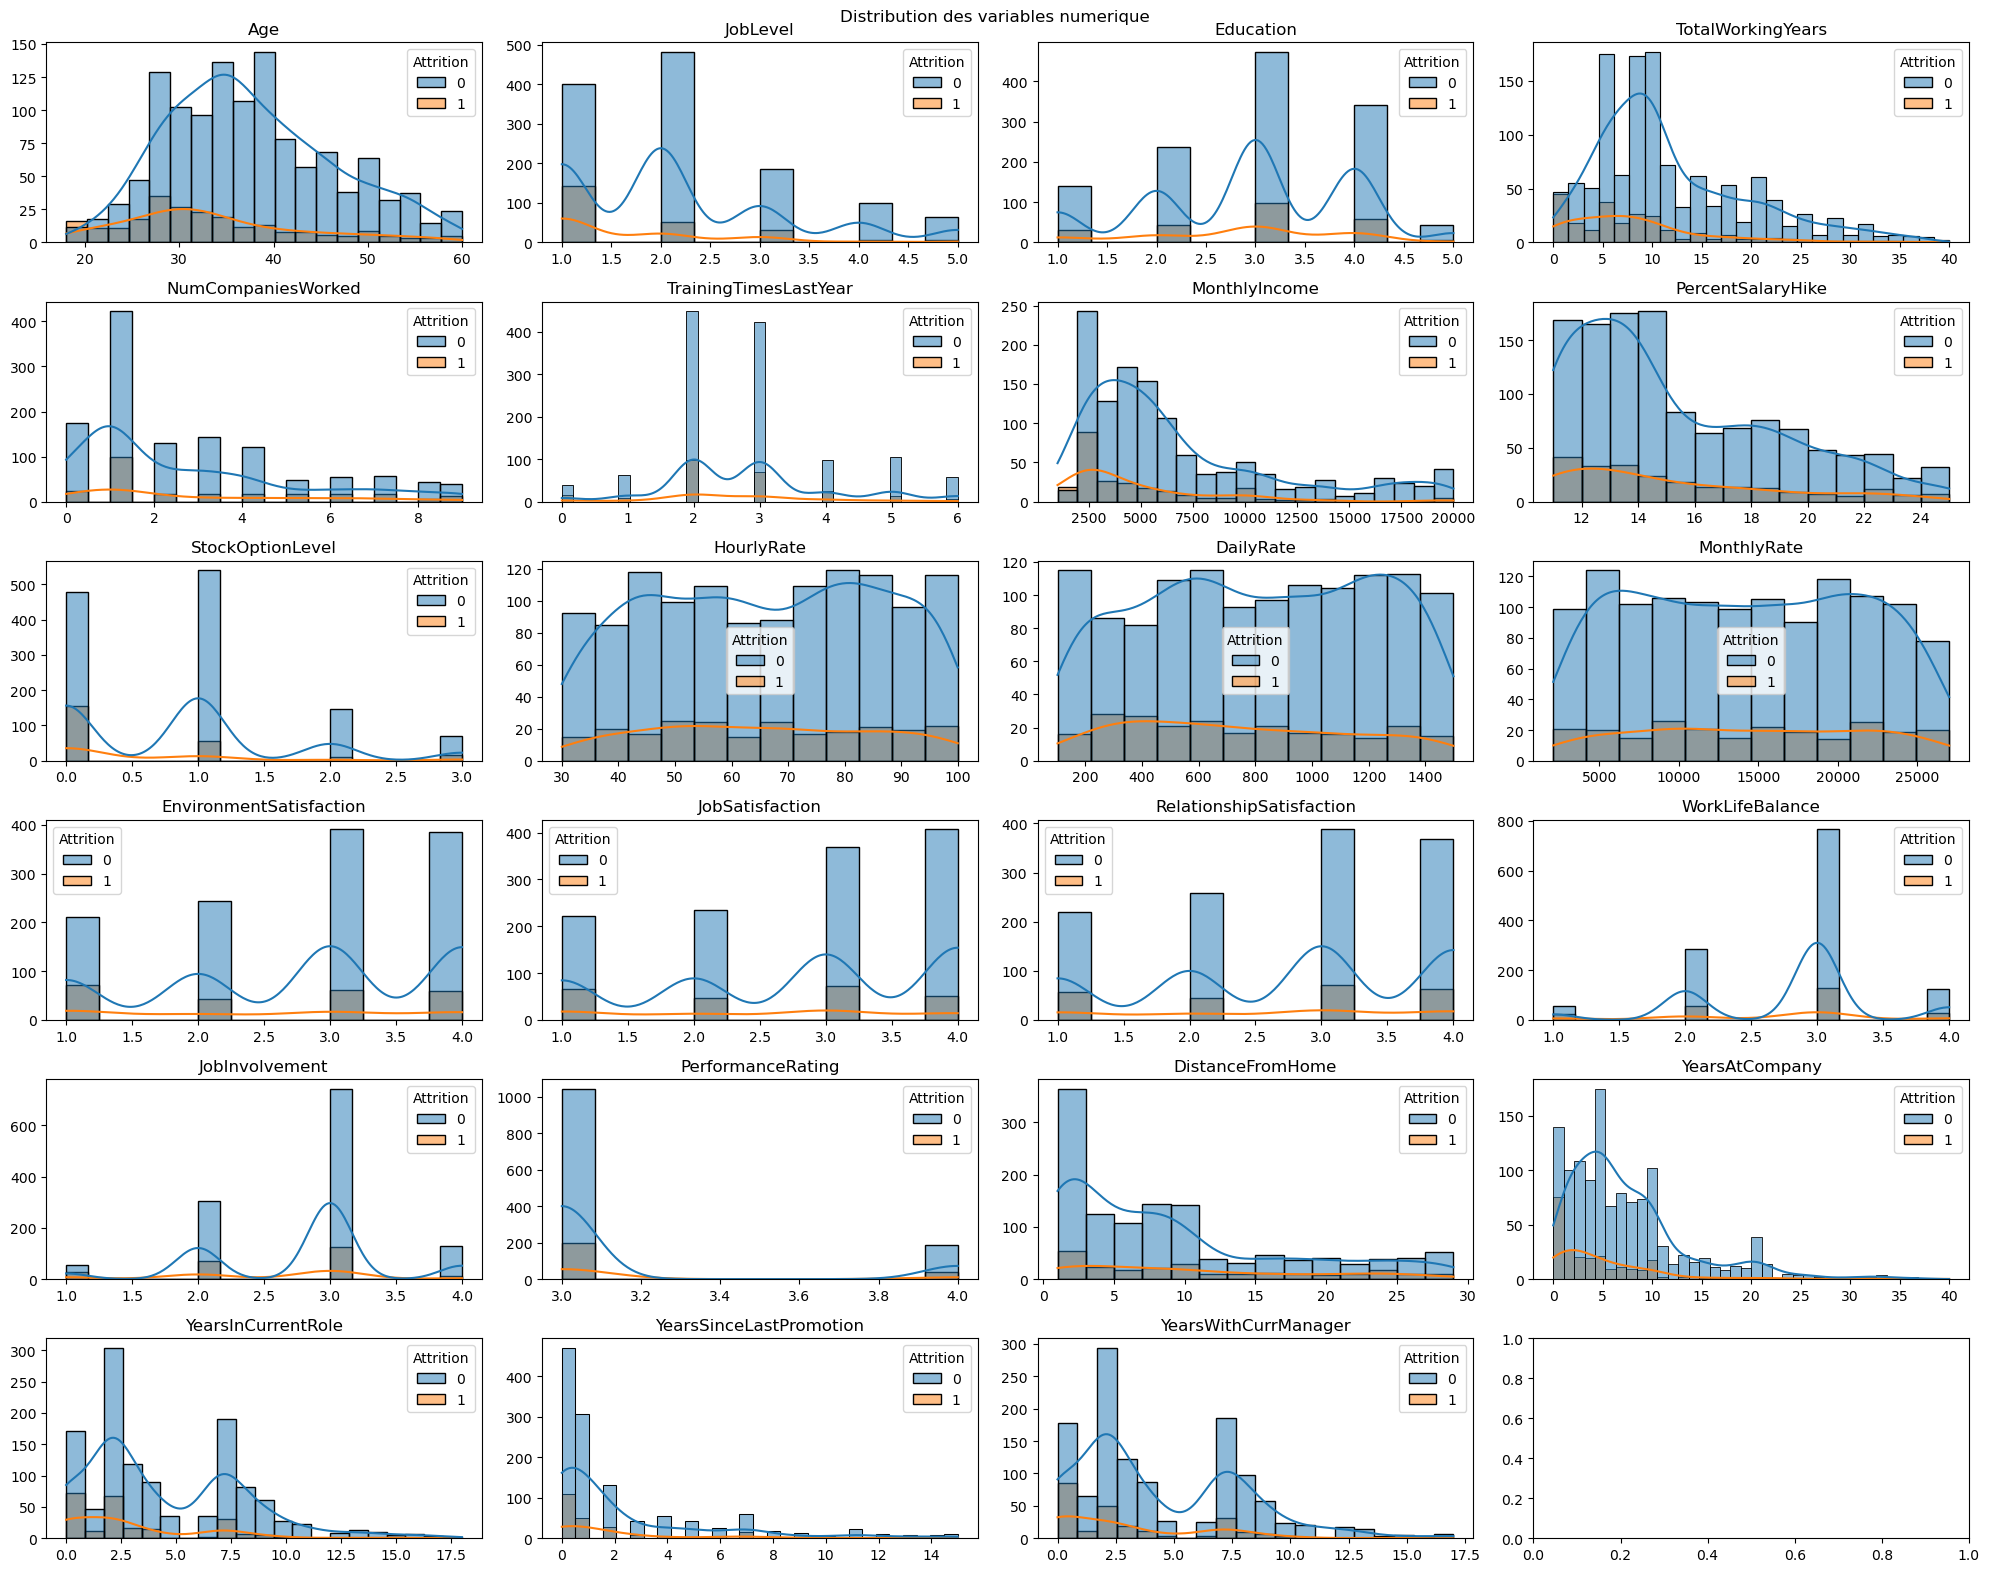

In [11]:
fig , ax = plt.subplots(nrows = 6 , ncols = 4 , figsize = (20 , 16))
ax = ax.flatten()
for i , col in enumerate(numeric_features):
    sns.histplot(
        data = df ,
        x = col ,
        hue = "Attrition",
        kde = True ,
        ax = ax [i]
    ) 
    ax[i].set_title(f"{col}")
    ax[i].set_xlabel("")
    ax[i].set_ylabel("")
plt.suptitle("Distribution des variables numerique")
plt.tight_layout()
plt.show()


* Visuelement nous pouvons confirmé nos observations sur la distributions des variables numérique sur les distribution ==> ❌ Les variables ne suivent pas une distribution **normale**

In [12]:
left = df.loc[df['Attrition'] == 1 , :].dropna()#.reset_index(drop = 'index').dropna()
stayed = df.loc[df["Attrition"] == 0, :].dropna()#.reset_index(drop='index').dropna()


In [13]:
# left.isna().sum()
# stayed.isna().sum()

In [14]:
# U, p_value = mannwhitneyu(
#     left["MonthlyIncome"], stayed["MonthlyIncome"], alternative="two-sided"
# )
# n1 = len(left["MonthlyIncome"])
# n2 = len(stayed["MonthlyIncome"])

# rank_biserial = (2*U/(n1 * n2)) -1
# print(f"U = {U:.2f}")
# print(f"p-value = {p_value:.3e}")
# print(f"Rank-biserial = {rank_biserial:.3f}")


In [15]:
from statsmodels.stats.multitest import multipletests



def numeric_feature_attrition_analysis(data, features, alpha=0.05):
    results = []

    for var in features:
        left = data.loc[data["Attrition"] == 1, var].dropna()
        stayed = data.loc[data["Attrition"] == 0, var].dropna()

        U, p_value = mannwhitneyu(left, stayed, alternative="two-sided")

        n1 = len(left)
        n2 = len(stayed)

        rank_biserial = (2 * U) / (n1 * n2) - 1

        results.append(
            {
                "Feature": var,
                "Mean_Left": left.mean(),
                "Mean_Stayed": stayed.mean(),
                "Median_Left": left.median(),
                "Median_Stayed": stayed.median(),
                "Difference_Mean": left.mean() - stayed.mean(),
                "U": U,
                "PValue": p_value,
                "Rank_Biserial": rank_biserial,
            }
        )

    results_df = pd.DataFrame(results)

    results_df["Significant_5pct"] = results_df["PValue"] < alpha

    abs_r = results_df["Rank_Biserial"].abs()

    results_df["Effect_Size"] = np.select(
        [abs_r < 0.10, abs_r < 0.30, abs_r < 0.49],
        ["Négligeable", "Faible", "Modérée"],
        default="Forte",
    )

    results_df["Direction"] = np.select(
        [results_df["Rank_Biserial"] < 0, results_df["Rank_Biserial"] > 0],
        ["Partis < Restés", "Partis > Restés"],
        default="Aucune dominance",
    )

    results_df["PValue_Adjusted"] = multipletests(
    results_df["PValue"],
    method="fdr_bh"
    )[1]

    results_df["Significant_FDR"] = (
    results_df["PValue_Adjusted"] < alpha
    )
    results_df["Abs_Effect"] = results_df["Rank_Biserial"].abs()

    results_df = results_df.sort_values(
    "Abs_Effect",
    ascending=False
    )
    return results_df


In [42]:

results = numeric_feature_attrition_analysis(df, numeric_features, alpha=0.05)

results


,Feature,Mean_Left,Mean_Stayed,Median_Left,Median_Stayed,Difference_Mean,U,PValue,Rank_Biserial,Significant_5pct,Effect_Size,Direction,PValue_Adjusted,Significant_FDR,Abs_Effect
3,TotalWorkingYears,8.244726,11.862936,7.0,10.0,-3.618210,100567.0,2.399569e-14,-0.311706,True,Modérée,Partis < Restés,3.393456e-13,True,0.311706
6,MonthlyIncome,4787.092827,6832.739659,3202.0,5204.0,-2045.646832,100620.5,2.950831e-14,-0.311340,True,Modérée,Partis < Restés,3.393456e-13,True,0.311340
19,YearsAtCompany,5.130802,7.369019,3.0,6.0,-2.238217,102582.0,2.916191e-13,-0.297915,True,Faible,Partis < Restés,1.700268e-12,True,0.297915
1,JobLevel,1.637131,2.145985,1.0,2.0,-0.508855,104729.5,2.956987e-13,-0.283217,True,Faible,Partis < Restés,1.700268e-12,True,0.283217
20,YearsInCurrentRole,2.902954,4.484185,2.0,3.0,-1.581231,105214.0,4.429560e-12,-0.279901,True,Faible,Partis < Restés,2.037597e-11,True,0.279901
22,YearsWithCurrManager,2.852321,4.367397,2.0,3.0,-1.515076,106361.5,1.806754e-11,-0.272048,True,Faible,Partis < Restés,6.925891e-11,True,0.272048
0,Age,33.607595,37.561233,32.0,36.0,-3.953638,106859.0,5.304342e-11,-0.268643,True,Faible,Partis < Restés,1.524998e-10,True,0.268643
8,StockOptionLevel,0.527426,0.845093,0.0,1.0,-0.317667,109611.0,4.013375e-11,-0.249808,True,Faible,Partis < Restés,1.318680e-10,True,0.249808
16,JobInvolvement,2.518987,2.770479,3.0,3.0,-0.251491,121957.0,4.651927e-06,-0.165310,True,Faible,Partis < Restés,1.188826e-05,True,0.165310
13,JobSatisfaction,2.468354,2.778589,3.0,3.0,-0.310234,123362.5,7.957918e-05,-0.155690,True,Faible,Partis < Restés,1.830321e-04,True,0.155690


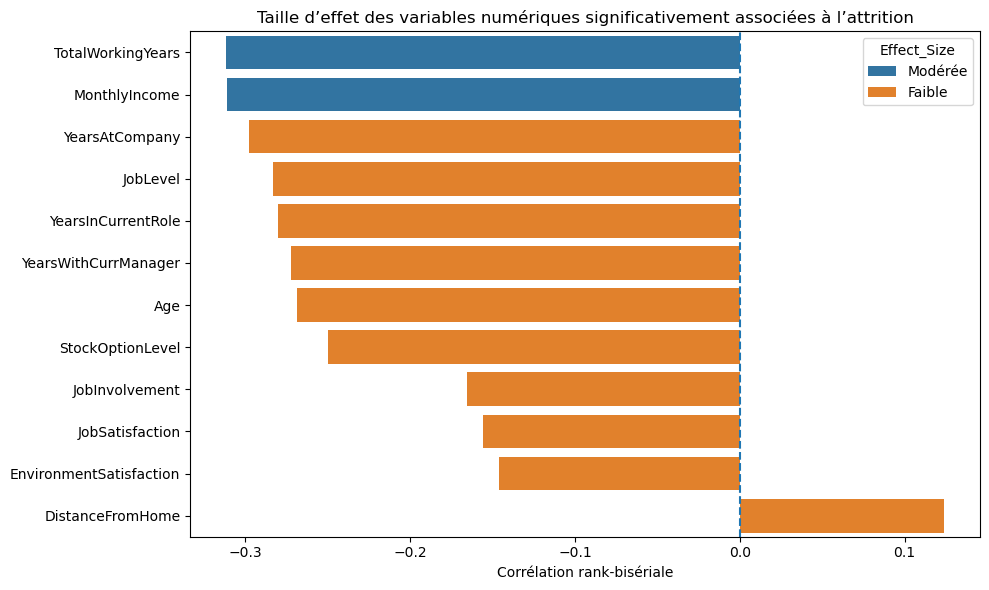

In [17]:
# Variables significatives après correction FDR
plot_results = results.query("Significant_FDR == True").copy()

# Classement par taille d'effet absolue
order = plot_results.sort_values("Abs_Effect", ascending=False)["Feature"]

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_results, y="Feature", x="Rank_Biserial", hue="Effect_Size", order=order
)

plt.axvline(0, linestyle="--")

plt.xlabel("Corrélation rank-bisériale")
plt.ylabel("")

plt.title(
    "Taille d’effet des variables numériques significativement associées à l’attrition"
)

plt.tight_layout()
plt.show()



Après correction de Benjamini-Hochberg (FDR = 5 %), 12 variables numériques
restent significativement associées à l'attrition.

Les associations les plus importantes concernent `TotalWorkingYears` et
`MonthlyIncome`, avec des corrélations rank-bisériales d'environ -0,31,
correspondant à des tailles d'effet modérées. Les collaborateurs ayant quitté
l'entreprise tendent ainsi à présenter une expérience professionnelle totale
et un revenu mensuel inférieurs à ceux des collaborateurs restés.

Plusieurs variables liées à l'ancienneté et au positionnement professionnel
(`YearsAtCompany`, `JobLevel`, `YearsInCurrentRole`,
`YearsWithCurrManager`) présentent également des associations négatives,
mais de plus faible amplitude.

À l'inverse, `DistanceFromHome` présente une association positive faible :
les collaborateurs partis tendent à résider légèrement plus loin de leur
lieu de travail.

Ces résultats décrivent des associations univariées et ne permettent pas
d'établir de relations causales. La redondance potentielle entre les variables
d'expérience, d'ancienneté, de niveau de poste et de rémunération devra être
étudiée avant la modélisation multivariée.

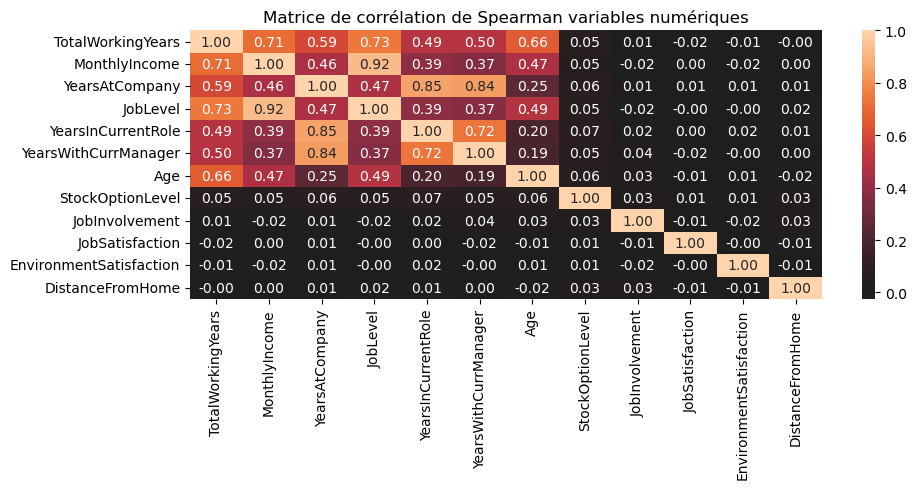

In [18]:
features = results.loc[results["Significant_FDR"], "Feature"].tolist()

spearman_corr = df[features].corr(method="spearman")



plt.figure(figsize=(10, 5))

sns.heatmap(spearman_corr, annot=True, fmt=".2f", center=0)

plt.title("Matrice de corrélation de Spearman variables numériques")

plt.tight_layout()
plt.show()


La corrélation de Spearman révèle plusieurs associations intéressantes entre les variables étudiées, dont certaines sont cohérentes avec la structure attendue des données RH.

On observe notamment une association positive entre le niveau du poste, l'expérience professionnelle et le revenu mensuel : les collaborateurs occupant des postes de niveau plus élevé tendent également à disposer de davantage d'expérience et à percevoir des revenus plus importants.

Ces résultats ne permettent toutefois pas d'établir de relation causale entre les variables. Ils mettent en évidence des tendances monotones dont l'intensité et la direction sont mesurées par le coefficient de Spearman.

Le tableau ci-dessous présente les associations les plus fortes identifiées dans le jeu de données, en retenant les couples de variables dont la valeur absolue du coefficient de Spearman est supérieure à 0,70.


In [19]:
corr_long = spearman_corr.stack().reset_index()
corr_long.columns = ["Var1" , "Var2" , "Corr_Spearman"]
corr_long.query("abs(Corr_Spearman) > 0.70 and Var1 != Var2").sort_values(by ='Corr_Spearman',ascending=False)


,Var1,Var2,Corr_Spearman
15,MonthlyIncome,JobLevel,0.920429
37,JobLevel,MonthlyIncome,0.920429
28,YearsAtCompany,YearsInCurrentRole,0.854000
50,YearsInCurrentRole,YearsAtCompany,0.854000
29,YearsAtCompany,YearsWithCurrManager,0.842803
62,YearsWithCurrManager,YearsAtCompany,0.842803
3,TotalWorkingYears,JobLevel,0.734678
36,JobLevel,TotalWorkingYears,0.734678
53,YearsInCurrentRole,YearsWithCurrManager,0.724754
64,YearsWithCurrManager,YearsInCurrentRole,0.724754


# 1.3 Test stat (Var Categorique vs Attrition)

In [20]:
categorical_features

['Gender',
 'MaritalStatus',
 'Department',
 'JobRole',
 'BusinessTravel',
 'EducationField',
 'OverTime',
 'Attrition']

In [ ]:
references = {
    "BusinessTravel": "Non-Travel",
    "Department": "Research & Development",
    "Gender": "Male",
    "MaritalStatus": "Single",
    "OverTime": "No",
}




In [24]:
def analyse_cat(df, feature, references, target="Attrition", event="Yes"):
    # Tableau de contingence
    table = pd.crosstab(df[feature], df[target])

    # Chi²
    chi2, p, dof, expected = chi2_contingency(table)

    # Cramér's V
    n = table.values.sum()

    v = np.sqrt(chi2 / (n * min(table.shape[0] - 1, table.shape[1] - 1)))

    # Résidus de Pearson
    expected = pd.DataFrame(expected, index=table.index, columns=table.columns)

    residuals = (table - expected) / np.sqrt(expected)

    # Référence
    reference = references.get(feature, df[feature].value_counts().idxmax())

    results = []

    # Comparaison de chaque catégorie à la référence
    for category in table.index:
        if category == reference:
            continue

        sub = df[df[feature].isin([category, reference])]

        # Tableau 2×2
        tab2 = pd.crosstab(sub[feature] == category, sub[target] == event).reindex(
            index=[True, False], columns=[True, False], fill_value=0
        )

        model = Table2x2(tab2.values)

        or_low, or_high = model.oddsratio_confint()

        rr_low, rr_high = model.riskratio_confint()

        results.append(
            {
                "Feature": feature,
                "Category": category,
                "Reference": reference,
                "Attrition_Rate": (
                    sub.loc[sub[feature] == category, target] == event
                ).mean(),
                "Residual": residuals.loc[category, event],
                "Chi2": chi2,
                "P_Value": p,
                "Cramers_V": v,
                "OR": model.oddsratio,
                "OR_Lower": or_low,
                "OR_Upper": or_high,
                "RR": model.riskratio,
                "RR_Lower": rr_low,
                "RR_Upper": rr_high,
            }
        )

    return pd.DataFrame(results)


In [25]:
references = {
    "BusinessTravel": "Non-Travel",
    "Department": "Research & Development",
    "Gender": "Male",
    "MaritalStatus": "Single",
    "OverTime": "No",
}


In [26]:
results = []

for col in [col for col in categorical_features if col != 'Attrition']:
    test = analyse_cat(
        df=data, feature=col, references=references, target="Attrition", event="Yes"
    )

    results.append(test)


In [32]:
results_df = pd.concat(results, ignore_index=True)
results_df["OR_Significant"] = (results_df["OR_Lower"] > 1) | (
    results_df["OR_Upper"] < 1
)

results_df["RR_Significant"] = (results_df["RR_Lower"] > 1) | (
    results_df["RR_Upper"] < 1
)

results_df["Abs_Residual"] = results_df["Residual"].abs()

results_df.sort_values("Abs_Residual", ascending=False)


,Feature,Category,Reference,Attrition_Rate,Residual,Chi2,P_Value,Cramers_V,OR,OR_Lower,OR_Upper,RR,RR_Lower,RR_Upper,OR_Significant,RR_Significant,Abs_Residual
20,OverTime,Yes,No,0.305288,7.317901,87.564294,8.158424e-21,0.244065,3.771249,2.829565,5.026327,2.925219,2.327272,3.676796,True,True,7.317901
12,JobRole,Sales Representative,Sales Executive,0.397590,5.363006,86.190254,2.752482e-15,0.242142,3.114737,1.843792,5.261756,2.273938,1.595075,3.241724,True,True,5.363006
13,BusinessTravel,Travel_Frequently,Non-Travel,0.249097,3.642334,24.182414,5.608614e-06,0.128260,3.814904,1.992167,7.305356,3.113718,1.743490,5.560823,True,True,3.642334
7,JobRole,Laboratory Technician,Sales Executive,0.239382,3.132611,86.190254,2.752482e-15,0.242142,1.485261,0.991727,2.224403,1.369098,0.993646,1.886417,False,False,3.132611
10,JobRole,Research Director,Sales Executive,0.025000,-3.034483,86.190254,2.752482e-15,0.242142,0.121008,0.028890,0.506849,0.142982,0.035662,0.573273,True,True,3.034483
8,JobRole,Manager,Sales Executive,0.049020,-2.822256,86.190254,2.752482e-15,0.242142,0.243263,0.094725,0.624725,0.280358,0.115511,0.680460,True,True,2.822256
9,JobRole,Manufacturing Director,Sales Executive,0.068966,-2.766796,86.190254,2.752482e-15,0.242142,0.349578,0.173067,0.706111,0.394434,0.207389,0.750176,True,True,2.766796
1,MaritalStatus,Divorced,Single,0.100917,-2.715980,46.163677,9.455511e-11,0.177211,0.327381,0.216121,0.495918,0.395260,0.276186,0.565670,True,True,2.715980
5,JobRole,Healthcare Representative,Sales Executive,0.068702,-2.637340,86.190254,2.752482e-15,0.242142,0.348145,0.166964,0.725934,0.392929,0.200435,0.770290,True,True,2.637340
4,Department,Sales,Research & Development,0.206278,2.369632,10.796007,4.525607e-03,0.085698,1.617943,1.206445,2.169797,1.490475,1.171407,1.896451,True,True,2.369632


In [33]:

# 1. Une seule p-value globale par variable
feature_pvalues = (
    results_df[["Feature", "P_Value"]].drop_duplicates(subset="Feature").copy()
)

# 2. Correction Benjamini-Hochberg
reject, pvals_corrected, _, _ = multipletests(
    feature_pvalues["P_Value"], alpha=0.05, method="fdr_bh"
)

feature_pvalues["PValue_Adjusted"] = pvals_corrected
feature_pvalues["Significant_FDR"] = reject

# 3. Réinjecter les résultats dans le tableau détaillé
results_df = results_df.merge(
    feature_pvalues[["Feature", "PValue_Adjusted", "Significant_FDR"]],
    on="Feature",
    how="left",
)

results_df = results_df.sort_values(
    ["Significant_FDR", "Cramers_V", "Abs_Residual"], ascending=[False, False, False]
)

categorical_summary = (
    results_df[
        [
            "Feature",
            "Chi2",
            "P_Value",
            "PValue_Adjusted",
            "Significant_FDR",
            "Cramers_V",
        ]
    ]
    .drop_duplicates(subset="Feature")
    .sort_values("Cramers_V", ascending=False)
)

categorical_summary

,Feature,Chi2,P_Value,PValue_Adjusted,Significant_FDR,Cramers_V
20,OverTime,87.564294,8.158424e-21,5.710897e-20,True,0.244065
12,JobRole,86.190254,2.752482e-15,9.633686e-15,True,0.242142
1,MaritalStatus,46.163677,9.455511e-11,2.206286e-10,True,0.177211
13,BusinessTravel,24.182414,5.608614e-06,9.815075e-06,True,0.128260
19,EducationField,16.024674,6.773980e-03,7.902977e-03,True,0.104409
4,Department,10.796007,4.525607e-03,6.335849e-03,True,0.085698
0,Gender,1.116967,2.905724e-01,2.905724e-01,False,0.027565


## Synthèse  Analyse des variables catégorielles

L'association entre les variables catégorielles et l'attrition a été étudiée à
l'aide du **test du Chi² d'indépendance**. La force des associations a ensuite
été quantifiée avec le **V de Cramér**.

Afin de limiter le risque de faux positifs lié aux comparaisons multiples,
les p-values ont été corrigées avec la procédure de **Benjamini-Hochberg
(FDR = 5 %)**.

### Principaux résultats

Six des sept variables catégorielles étudiées restent significativement
associées à l'attrition après correction FDR :

| Variable | V de Cramér | p-value ajustée | Interprétation |
|---|---:|---:|---|
| OverTime | 0.244 | < 0.001 | Association la plus importante |
| JobRole | 0.242 | < 0.001 | Association notable |
| MaritalStatus | 0.177 | < 0.001 | Association faible |
| BusinessTravel | 0.128 | < 0.001 | Association faible |
| EducationField | 0.104 | 0.008 | Association faible |
| Department | 0.086 | 0.006 | Association très faible |
| Gender | 0.028 | 0.291 | Association non significative |

`OverTime` et `JobRole` présentent les associations les plus importantes avec
l'attrition parmi les variables catégorielles étudiées.

Les collaborateurs effectuant des heures supplémentaires présentent notamment
un taux d'attrition de **30,5 %**. Par rapport aux collaborateurs sans heures
supplémentaires, leur risque observé d'attrition est environ **2,93 fois plus
élevé** (RR ≈ 2,93), tandis que leurs odds d'attrition sont environ **3,77 fois
plus élevées** (OR ≈ 3,77).

Le rôle professionnel contribue également fortement aux différences
d'attrition. Les `Sales Representative` présentent notamment un taux
d'attrition proche de **39,8 %**, alors que plusieurs fonctions plus
expérimentées ou hiérarchiquement élevées présentent des taux nettement plus
faibles.

`MaritalStatus` et `BusinessTravel` présentent également des associations
statistiquement robustes, mais d'amplitude plus faible. `EducationField` et
`Department`, bien que significatifs après correction FDR, présentent des
tailles d'association relativement faibles et devront donc être interprétés
avec davantage de prudence.

Enfin, aucune association statistiquement significative n'a été détectée entre
`Gender` et l'attrition (V de Cramér = 0.028 ; p-ajustée = 0.291).

### Interprétation méthodologique

La significativité statistique ne doit pas être confondue avec l'importance
métier d'une variable. Les résultats sont donc interprétés conjointement à
partir :

- de la p-value ajustée ;
- du V de Cramér ;
- des résidus standardisés ;
- des Odds Ratios et Risk Ratios avec leurs intervalles de confiance ;
- de la pertinence métier des associations observées.

Ces analyses restent **univariées** : elles mettent en évidence des
associations entre chaque caractéristique et l'attrition, mais ne permettent
ni d'établir une relation causale ni de déterminer si une association reste
présente après contrôle des autres caractéristiques.

La modélisation multivariée permettra ultérieurement d'évaluer les facteurs
conjointement.

## 7. Sélection et redondance des variables

Les analyses précédentes ont permis d'identifier les variables associées
individuellement à l'attrition. Cependant, plusieurs prédicteurs peuvent
représenter des dimensions similaires.

Avant la modélisation, la sélection des variables repose donc conjointement
sur leur significativité statistique, leur taille d'effet, leur redondance
et leur pertinence métier.

Les corrélations de Spearman sont utilisées pour identifier les redondances
potentielles entre variables numériques. La multicolinéarité sera ensuite
évaluée afin de préparer la modélisation multivariée.

In [43]:
numeric_summary = (
    results[
        [
            "Feature",
            "PValue_Adjusted",
            "Significant_FDR",
            "Rank_Biserial",
            "Abs_Effect",
            "Effect_Size",
        ]
    ]
    .copy()
    .sort_values("Abs_Effect", ascending=False)
)

numeric_summary


,Feature,PValue_Adjusted,Significant_FDR,Rank_Biserial,Abs_Effect,Effect_Size
3,TotalWorkingYears,3.393456e-13,True,-0.311706,0.311706,Modérée
6,MonthlyIncome,3.393456e-13,True,-0.311340,0.311340,Modérée
19,YearsAtCompany,1.700268e-12,True,-0.297915,0.297915,Faible
1,JobLevel,1.700268e-12,True,-0.283217,0.283217,Faible
20,YearsInCurrentRole,2.037597e-11,True,-0.279901,0.279901,Faible
22,YearsWithCurrManager,6.925891e-11,True,-0.272048,0.272048,Faible
0,Age,1.524998e-10,True,-0.268643,0.268643,Faible
8,StockOptionLevel,1.318680e-10,True,-0.249808,0.249808,Faible
16,JobInvolvement,1.188826e-05,True,-0.165310,0.165310,Faible
13,JobSatisfaction,1.830321e-04,True,-0.155690,0.155690,Faible


In [44]:
import numpy as np

upper = spearman_corr.where(np.triu(np.ones(spearman_corr.shape), k=1).astype(bool))

strong_correlations = upper.stack().reset_index()

strong_correlations.columns = ["Feature_1", "Feature_2", "Spearman_Rho"]

strong_correlations["Abs_Rho"] = strong_correlations["Spearman_Rho"].abs()

strong_correlations = strong_correlations.query("Abs_Rho >= 0.70").sort_values(
    "Abs_Rho", ascending=False
)

strong_correlations


,Feature_1,Feature_2,Spearman_Rho,Abs_Rho
12,MonthlyIncome,JobLevel,0.920429,0.920429
22,YearsAtCompany,YearsInCurrentRole,0.854000,0.854000
23,YearsAtCompany,YearsWithCurrManager,0.842803,0.842803
2,TotalWorkingYears,JobLevel,0.734678,0.734678
38,YearsInCurrentRole,YearsWithCurrManager,0.724754,0.724754
0,TotalWorkingYears,MonthlyIncome,0.710024,0.710024


In [45]:

upper = spearman_corr.where(np.triu(np.ones(spearman_corr.shape), k=1).astype(bool))

strong_correlations = upper.stack().reset_index()

strong_correlations.columns = ["Feature_1", "Feature_2", "Spearman_Rho"]

strong_correlations["Abs_Rho"] = strong_correlations["Spearman_Rho"].abs()

strong_correlations = strong_correlations.query("Abs_Rho >= 0.70").sort_values(
    "Abs_Rho", ascending=False
)

strong_correlations


,Feature_1,Feature_2,Spearman_Rho,Abs_Rho
12,MonthlyIncome,JobLevel,0.920429,0.920429
22,YearsAtCompany,YearsInCurrentRole,0.854000,0.854000
23,YearsAtCompany,YearsWithCurrManager,0.842803,0.842803
2,TotalWorkingYears,JobLevel,0.734678,0.734678
38,YearsInCurrentRole,YearsWithCurrManager,0.724754,0.724754
0,TotalWorkingYears,MonthlyIncome,0.710024,0.710024


In [47]:
import statsmodels.api as sm

selected_numeric = numeric_summary.loc[
    numeric_summary["Significant_FDR"],
    "Feature"
].tolist()

X_vif = df[selected_numeric].copy()

X_vif = sm.add_constant(X_vif)

vif_results = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif_results = (
    vif_results
    .query("Feature != 'const'")
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

vif_results["Diagnostic"] = pd.cut(
    vif_results["VIF"],
    bins=[0, 5, 10, float("inf")],
    labels=["Acceptable", "À surveiller", "Multicolinéarité forte"],
)

vif_results

,Feature,VIF,Diagnostic
0,JobLevel,11.133578,Multicolinéarité forte
1,MonthlyIncome,10.760832,Multicolinéarité forte
2,TotalWorkingYears,4.518181,Acceptable
3,YearsAtCompany,4.006736,Acceptable
4,YearsWithCurrManager,2.762187,Acceptable
5,YearsInCurrentRole,2.630288,Acceptable
6,Age,1.961413,Acceptable
7,StockOptionLevel,1.008840,Acceptable
8,JobInvolvement,1.008350,Acceptable
9,DistanceFromHome,1.007740,Acceptable


In [49]:
selected_numeric_v2 = [feature for feature in selected_numeric if feature != "JobLevel"]

X_vif_v2 = df[selected_numeric_v2].copy()
X_vif_v2 = sm.add_constant(X_vif_v2)

vif_results_v2 = pd.DataFrame(
    {
        "Feature": X_vif_v2.columns,
        "VIF": [
            variance_inflation_factor(X_vif_v2.values, i)
            for i in range(X_vif_v2.shape[1])
        ],
    }
)

vif_results_v2 = (
    vif_results_v2.query("Feature != 'const'")
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

vif_results_v2["Diagnostic"] = pd.cut(
    vif_results_v2["VIF"],
    bins=[0, 5, 10, float("inf")],
    labels=["Acceptable", "À surveiller", "Multicolinéarité forte"],
)

vif_results_v2


,Feature,VIF,Diagnostic
0,TotalWorkingYears,4.425688,Acceptable
1,YearsAtCompany,4.006381,Acceptable
2,YearsWithCurrManager,2.756230,Acceptable
3,YearsInCurrentRole,2.629010,Acceptable
4,MonthlyIncome,2.520023,Acceptable
5,Age,1.960225,Acceptable
6,StockOptionLevel,1.008455,Acceptable
7,JobInvolvement,1.008350,Acceptable
8,DistanceFromHome,1.003796,Acceptable
9,JobSatisfaction,1.003162,Acceptable


### Diagnostic de multicolinéarité

L'analyse des corrélations de Spearman a mis en évidence plusieurs relations
importantes entre les variables décrivant l'expérience, l'ancienneté et le
positionnement professionnel.

Le diagnostic par VIF montre cependant que la multicolinéarité problématique
se concentre principalement sur `JobLevel` (VIF = 11,13) et `MonthlyIncome`
(VIF = 10,76). Ces deux variables présentent également une très forte
corrélation de Spearman (ρ = 0,92), indiquant qu'elles véhiculent une
information largement redondante.

Les autres variables présentent des VIF inférieurs à 5. Ainsi, malgré certaines
corrélations bivariées élevées entre les variables d'ancienneté, aucune
multicolinéarité sévère supplémentaire n'est détectée selon ce diagnostic.

Pour préparer une régression logistique interprétable, `MonthlyIncome` est
provisoirement privilégié par rapport à `JobLevel`, en raison de sa taille
d'association légèrement supérieure avec l'attrition et de son interprétation
métier directe.

### Conclusion du diagnostic de multicolinéarité

Après retrait de `JobLevel`, fortement redondant avec `MonthlyIncome`
(ρ de Spearman = 0,92), l'ensemble des variables numériques restantes
présente un VIF inférieur à 5.

Selon le seuil retenu, aucune multicolinéarité préoccupante n'est donc
détectée dans cette nouvelle spécification.

`MonthlyIncome` est conservé pour la suite de la modélisation en raison de
son association légèrement plus importante avec l'attrition et de son
interprétation métier directe.

